In [1]:
import numpy as np

def compute_A(rho, v, T, L, lanes, params):
    """
    Compute the state Jacobian A_t at a given state (rho, v).
    
    rho    : array of shape (N,) - segment densities
    v      : array of shape (N,) - segment speeds
    T      : scalar - time step
    L      : scalar - segment length
    lanes  : array of shape (N,) - number of lanes per segment
    params : dict with keys tau, eta_high, K, v_free, p_crit, a,
             each an array of shape (N,) indexed by segment
    """
    lam    = lanes
    tau    = params['tau']       # shape (N,)
    nu     = params['eta_high']  # shape (N,)
    kap    = params['K']         # shape (N,)
    v_f    = params['v_free']    # shape (N,)
    rho_cr = params['p_crit']    # shape (N,)
    alpha  = params['a']         # shape (N,)
    N = len(rho)

    A = np.zeros((2*N, 2*N))

    for i in range(N):
        # segment-specific parameters
        tau_i    = tau[i]
        nu_i     = nu[i]
        kap_i    = kap[i]
        v_f_i    = v_f[i]
        rho_cr_i = rho_cr[i]
        alpha_i  = alpha[i]

        # V'(rho_i) using segment-specific parameters
        dV_i = -(v_f_i / rho_cr_i) * (rho[i] / rho_cr_i)**(alpha_i - 1) \
               * np.exp(-(1/alpha_i) * (rho[i] / rho_cr_i)**alpha_i)

        # --- Block 1: d(rho_{i+1}) / d(rho) ---
        # self term
        A[i, i] = 1 - (T / (L * lam[i])) * v[i]
        # upstream neighbour
        if i > 0:
            A[i, i-1] = (T / (L * lam[i])) * v[i-1]

        # --- Block 2: d(rho_{i+1}) / d(v) ---
        # self term
        A[i, N+i] = -(T / (L * lam[i])) * rho[i]
        # upstream neighbour
        if i > 0:
            A[i, N+i-1] = (T / (L * lam[i])) * rho[i-1]

        # --- Block 3: d(v_{i+1}) / d(rho) ---
        # self term
        rho_next = rho[i+1] if i < N-1 else rho[i]  # boundary condition
        A[N+i, i] = (T/tau_i) * dV_i + (nu_i*T/(tau_i*L)) \
                    * (rho_next - rho[i] + rho[i] + kap_i) / (rho[i] + kap_i)**2
        # downstream neighbour
        if i < N-1:
            A[N+i, i+1] = -(nu_i*T) / (tau_i * L * (rho[i] + kap_i))

        # --- Block 4: d(v_{i+1}) / d(v) ---
        # self term
        v_prev = v[i-1] if i > 0 else v[i]  # boundary condition
        A[N+i, N+i] = 1 - T/tau_i + (T/L) * (v_prev - 2*v[i])
        # upstream neighbour
        if i > 0:
            A[N+i, N+i-1] = (T/L) * v[i]

    return A


def compute_B(T, L, lanes):
    """
    Compute the demand Jacobian B (time-invariant).
    """
    lam = lanes
    N   = len(lanes)
    onramp_segments = []  # list of segment indices with on-ramps
    m   = 1 + len(onramp_segments)

    B = np.zeros((2*N, m))
    # upstream boundary flow hits segment 0
    B[0, 0] = T / (L * lam[0])
    # on-ramp flows
    for col, seg in enumerate(onramp_segments, start=1):
        B[seg, col] = T / (L * lam[seg])

    return B

def compute_M_phi(A_list):
    """
    Compute M = sup_{i <= j} ||Phi_{j,i}||_op by explicitly computing
    all O(T^2) transition matrix products using partial product reuse.

    trajectory_rho : array (T_steps, N)
    trajectory_v   : array (T_steps, N)

    Returns
    -------
    M        : scalar, the maximum operator norm over all (i, j) pairs
    M_matrix : array (T_steps, T_steps), M_matrix[i, j] = ||Phi_{j,i}||
               upper triangular, zeros elsewhere
    """
    T_steps = len(A_list)
    n       = A_list[0].shape[0]  # state dimension 2N

    # # precompute all Jacobians once
    # A_list = []
    # for t in range(T_steps):
    #     A = compute_A(
    #         trajectory_rho[t], trajectory_v[t],
    #         T, L, lanes, params
    #     )
    #     A_list.append(A)

    M_matrix = np.zeros((T_steps, T_steps))
    M        = 0.0

    for i in range(T_steps):
        # Phi_{i,i} = I by convention
        Phi = np.eye(n)
        M_matrix[i, i] = 1.0

        for j in range(i + 1, T_steps):
            # Phi_{j,i} = A_{j-1} @ Phi_{j-1,i}
            Phi = A_list[j - 1] @ Phi
            norm_ij = np.linalg.norm(Phi, ord=2)  # largest singular value
            M_matrix[i, j] = norm_ij
            if norm_ij > M:
                M = norm_ij

    return M, M_matrix


def compute_M_gamma(trajectory_rho, trajectory_v, params, lanes, T, L):
    """
    trajectory_rho : array of shape (T_steps, N)
    trajectory_v   : array of shape (T_steps, N)
    params         : dict with segment-indexed arrays of shape (N,)
    lanes          : array of shape (N,)
    T              : scalar - time step
    L              : scalar - segment length
    """
    T_steps = trajectory_rho.shape[0]
    B = compute_B(T, L, lanes)
    gamma = np.linalg.norm(B, ord=2)  # largest singular value

    norms = []
    A_matrices = []

    # print(len(params['tau'].shape))
    
    for t in range(T_steps):
        if len(params['tau'].shape) == 1:
            params_t = params.copy()
        else:
            params_t = dict()
            for key in params:
                params_t[key] = params[key][t]

        A = compute_A(trajectory_rho[t], trajectory_v[t], T, L, lanes, params_t)
        norms.append(np.linalg.norm(A, ord=2))
        A_matrices.append(A)

    M = max(norms)
    M_phi = compute_M_phi(A_matrices)[0]
    return M, gamma, norms, A_matrices, M_phi

In [2]:
from optimization_utils import smooth_inflow

real_data = True

if real_data:
    # #### I-linewid4 Data
    q_hat = np.load("data/flow_10sec_400m_1hr.npy")#[240:270, :]
    rho_hat = np.load("data/density_10sec_400m_1hr.npy")#[240:270, :]
    v_hat = q_hat / rho_hat

    num_calibrated_segments = rho_hat.shape[1] - 2
    lane_map = np.load("data/lane_mapping.npy")
    lane_mapping = {i: float(lane_map[i+1]) for i in range(len(lane_map)-2)}
    lanes = np.array([lane_mapping[i] for i in range(num_calibrated_segments)])

    ramp_mapping = {"on_ramps": np.load("data/on_ramp_mapping.npy")[1:-1], "off_ramps": np.load("data/off_ramp_mapping.npy")[1:-1]}

    downstream_density = smooth_inflow(rho_hat[:, -1]) / lane_map[-1]
    data_inflow = smooth_inflow(q_hat[:, 0])
    init_traffic_state = (rho_hat[0, 1:-1]/lanes, v_hat[0, 1:-1], data_inflow[0], 0)

    rho_hat = rho_hat[:, 1:-1]
    q_hat = q_hat[:, 1:-1]
    v_hat = v_hat[:, 1:-1]
    
else:
    variance = 0.1
    q_hat = np.load(f"data/synthetic_dynamic_rain/q_synthetic_var{variance}.npy") #np.load("data/flow_10sec_400m_1hr.npy")
    rho_hat = np.load(f"data/synthetic_dynamic_rain/p_synthetic_var{variance}.npy") #np.load("data/density_10sec_400m_1hr.npy")
    v_hat = q_hat / rho_hat

    num_calibrated_segments = rho_hat.shape[1]
    lanes = np.array([4 if i < num_calibrated_segments - 5 else 2 for i in range(num_calibrated_segments)])

    downstream_density = np.full(rho_hat.shape[0], 0)
    data_inflow = np.array([5500 if i in range(20, 20 + 90) else 4000 for i in range(rho_hat.shape[0])])
    init_traffic_state = (rho_hat[0, :]/lanes, v_hat[0, :], data_inflow[0], 0)


In [3]:
print(init_traffic_state)
print(11.1111 * 90)

(array([10.18249925,  8.05499963, 11.30499944,  7.68499438,  5.6259996 ,
        6.02199973,  6.41799985,  3.7299995 ,  7.91030399,  7.48749975,
        6.50249969,  9.4502994 ,  7.00450656,  9.57499925]), array([15.60562109, 22.63969379, 14.53123911, 33.0528382 , 44.74894381,
       40.31822336, 36.43426698, 50.4408325 , 24.55019846, 12.00645115,
        5.34702448, 21.88636564, 40.55200066, 44.41112619]), np.float64(762.7968000000619), 0)
999.999


In [4]:
import matplotlib.pyplot as plt

(360, 14)
(360, 14)


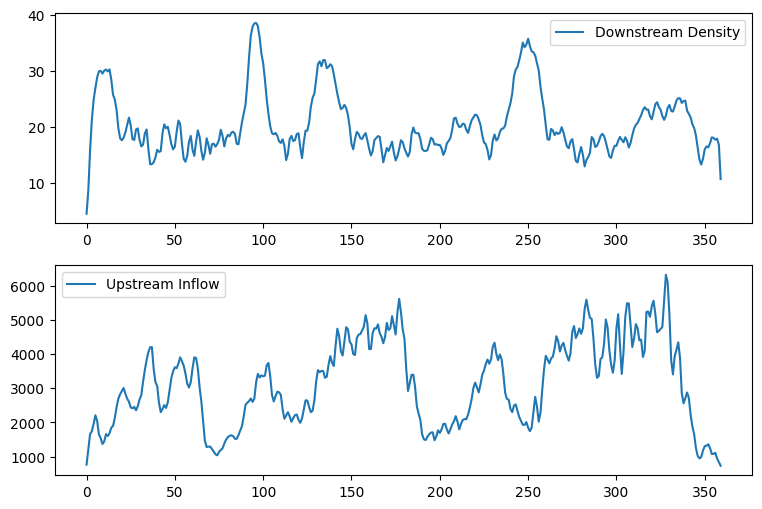

In [5]:
print(rho_hat.shape)
print(q_hat.shape)

plt.figure(figsize=(9, 6))
plt.subplot(2, 1, 1)
# plt.plot(rho_hat[:, 0], label="Density")
plt.plot(downstream_density, label="Downstream Density")
plt.legend()
plt.subplot(2, 1, 2)
# plt.plot(q_hat[:, 0], label="Flow")
plt.plot(data_inflow, label="Upstream Inflow")
plt.legend()
plt.show()


In [6]:
print(f"Bounds on rho: {np.min(rho_hat)} to {np.max(rho_hat)}")
print(f"Bounds on q: {np.min(q_hat)} to {np.max(q_hat)}")
print(f"Bounds on v: {np.min(v_hat)} to {np.max(v_hat)}")

Bounds on rho: 16.6199985 to 225.06999625000026
Bounds on q: 139.07610000000858 to 6749.992799999934
Bounds on v: 3.114799360447148 to 102.5494591064967


In [7]:
T = 10 / 3600
l = 0.4

In [ ]:
from param_loader import METANET_Params
from simulation_utils import run_metanet_sim
path = None if not real_data else "itsc_final/calibration_results/OCP"
control_h = None 

if real_data:
    calibrated_params = METANET_Params(path="itsc_final/calibration_results/OCP", num_segments=num_calibrated_segments, 
                                    control_h = None, num_timesteps=rho_hat.shape[0]).get_params()

    dynamic_params = METANET_Params(path="itsc_final/mpc_calibration_results" , num_segments=num_calibrated_segments, 
                                    control_h = 90, num_timesteps=rho_hat.shape[0]).get_params()

if not real_data:
    calibrated_params = METANET_Params(path="cdc_results/synthetic_data_rain/mpc_calibration_results_var0.1", num_segments=num_calibrated_segments, 
                                    control_h = 360, num_timesteps=rho_hat.shape[0]).get_params()

    dynamic_params = METANET_Params(path="cdc_results/synthetic_data_rain/mpc_calibration_results_var0.1" , num_segments=num_calibrated_segments, 
                                    control_h = 1, num_timesteps=rho_hat.shape[0]).get_params()

# TODO: Ignoring on ramp demand for now

In [10]:
rho_sim, v_sim, _, tts_sim = run_metanet_sim(
    T, 
    l, 
    init_traffic_state,
    data_inflow,
    downstream_density,
    calibrated_params,
    vsl_speeds=None,
    lanes={i: lanes[i] for i in range(num_calibrated_segments)},
    plotting=True,
    real_data=True
)
rho_sim = rho_sim[0:-1, :]
v_sim = v_sim[0:-1, :]

In [11]:
dyn_rho_sim, dyn_v_sim, _, tts_sim = run_metanet_sim(
    T, 
    l, 
    init_traffic_state,
    data_inflow,
    downstream_density,
    dynamic_params,
    vsl_speeds=None,
    lanes={i: lanes[i] for i in range(num_calibrated_segments)},
    plotting=True,
    real_data=True
)
dyn_rho_sim = dyn_rho_sim[0:-1, :]
dyn_v_sim = dyn_v_sim[0:-1, :]

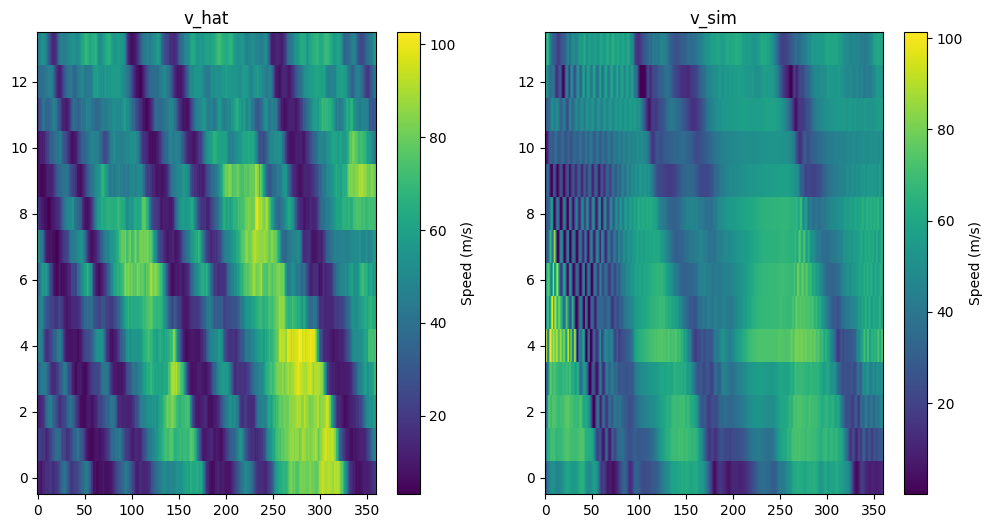

In [12]:
# Plot v hat and v sim side by side as a heatmap
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("v_hat")
plt.imshow(v_hat.T, aspect='auto', cmap='viridis', origin='lower', interpolation="none")
plt.colorbar(label='Speed (m/s)')
plt.subplot(1, 2, 2)
plt.title("v_sim")
plt.imshow(v_sim.T, aspect='auto', cmap='viridis', origin='lower', interpolation="none")
plt.colorbar(label='Speed (m/s)')
plt.show()

In [13]:
def calculate_J_cost(v_sim, v_hat, p_sim, p_hat, T):
    """
    v_sim : array of shape (T_steps, N) - simulated speed trajectory
    v_hat : array of shape (T_steps, N) - observed speed trajectory
    p_sim : array of shape (T_steps, N) - simulated density trajectory
    p_hat : array of shape (T_steps, N) - observed density trajectory
    """
    # Combine v_sim and p_sim into a single array of shape (T_steps, 2N) for comparison with v_hat and p_hat
    x_sim = np.hstack((v_sim[0:T, :], p_sim[0:T, :]))  # shape (T_steps, 2N)
    x_hat = np.hstack((v_hat[0:T, :], p_hat[0:T, :]))
    return np.sum((x_sim - x_hat)**2)

In [14]:
print(rho_hat.shape)
print(lanes.shape)
M, gamma, A_norms, A_mat, M_phi = compute_M_gamma(rho_hat, v_hat, calibrated_params, lanes, T, l)
M_dyn, gamma_dyn, A_norms_dyn, A_mat_dyn, M_phi_dyn = compute_M_gamma(rho_hat, v_hat, dynamic_params, lanes, T, l)

print("-------For static calibrated parameters:")
print(f"M: {M}")
print(f"Product of norms of A: {np.prod(A_norms)}")
print(f"Norm of product of A: {np.linalg.norm(np.linalg.multi_dot(A_mat), ord=2)}")
print(f"gamma: {gamma}")
print(f"Max value of Phi: {M_phi}")

print("------- For dynamic calibrated parameters:")
print(f"M: {M_dyn}")
print(f"Product of norms of A: {np.prod(A_norms_dyn)}")
print(f"Norm of product of A: {np.linalg.norm(np.linalg.multi_dot(A_mat_dyn), ord=2)}")
print(f"gamma: {gamma_dyn}")
print(f"Max value of Phi: {M_phi_dyn}")

(360, 14)
(14,)
-------For static calibrated parameters:
M: 4.350966522956268
Product of norms of A: 1.5134866493868525e+106
Norm of product of A: 0.029416941944131234
gamma: 0.001736111111111111
Max value of Phi: 5.296769860916323
------- For dynamic calibrated parameters:
M: 5.948438395246988
Product of norms of A: 5.066349760475823e+129
Norm of product of A: 0.023437387922863134
gamma: 0.001736111111111111
Max value of Phi: 5.948438395246988


1.2654142003793376


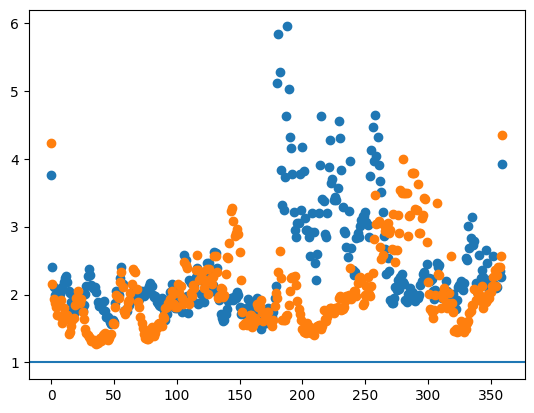

In [15]:
plt.scatter([t for t in range(len(A_norms_dyn))], A_norms_dyn)
plt.scatter([t for t in range(len(A_norms))], A_norms)
plt.axhline(1)
print(np.min(A_norms))

In [16]:
def calculate_phi(A_mat, j, i):
    A_mat_reversed = A_mat[::-1]
    assert j >= i, "j must be greater than or equal to i"
    if j == i:
        return np.eye(A_mat[0].shape[0])
    else:
        # Map i and j to the reversed indexing        
        i_reversed = len(A_mat) - 1 - i
        j_reversed = len(A_mat) - 1 - j
        # print(len(A_mat_reversed[j_reversed+1:i_reversed+1]))
        # print(j-i)
        mats_to_multiply = A_mat_reversed[j_reversed+1:i_reversed+1]
        if len(mats_to_multiply) == 1:
            return mats_to_multiply[0]
        else:
            return np.linalg.multi_dot(A_mat_reversed[j_reversed+1:i_reversed+1])

def calc_G_t(M, gamma, epsilon, t, A_norm=None, A_mat=None, M_phi=None):
    if M_phi is not None:
        return gamma * epsilon * M_phi * t
    
    elif A_mat is not None:
        phi = 0
        for i in range(0, t):
            phi += np.linalg.norm(calculate_phi(A_mat, t-1, i), ord=2)
        return gamma * epsilon * phi

    elif A_norm is not None: 
        A_norm_prod_sum = 0
        for i in range(1, t):
            A_norm_prod = 1
            for j in range(i, t):
                A_norm_prod = A_norm_prod * A_norm[j]
            A_norm_prod_sum += A_norm_prod
        return gamma * epsilon * A_norm_prod_sum
    
    else:
        return gamma * epsilon * (1 - M**t) / (1 - M)
        

def calc_G_summation(M, gamma, epsilon, T_steps, A_norm=None, A_mat=None, M_phi=None):
    total = 0
    for t in range(T_steps):
        total += (calc_G_t(M, gamma, epsilon, t, A_norm=A_norm, A_mat=A_mat, M_phi=M_phi))**2
    return total

def first_term(M, gamma, epsilon, T_steps, A_norm=None, A_mat=None, M_phi=None):
    return calc_G_summation(M, gamma, epsilon, T_steps, A_norm=A_norm, A_mat=A_mat,  M_phi=M_phi)

def second_term(M, gamma, epsilon, T_steps, v_sim, v_hat, rho_sim, rho_hat, A_norm=None, A_mat=None, M_phi=None):
    return np.sqrt(calc_G_summation(M, gamma, epsilon, T_steps, A_norm=A_norm,  A_mat=A_mat,  M_phi=M_phi)) \
        * np.sqrt(calculate_J_cost(v_sim, v_hat, rho_sim, rho_hat, T_steps)) * 2

In [47]:
phi_test = calculate_phi(A_mat, 10, 5)

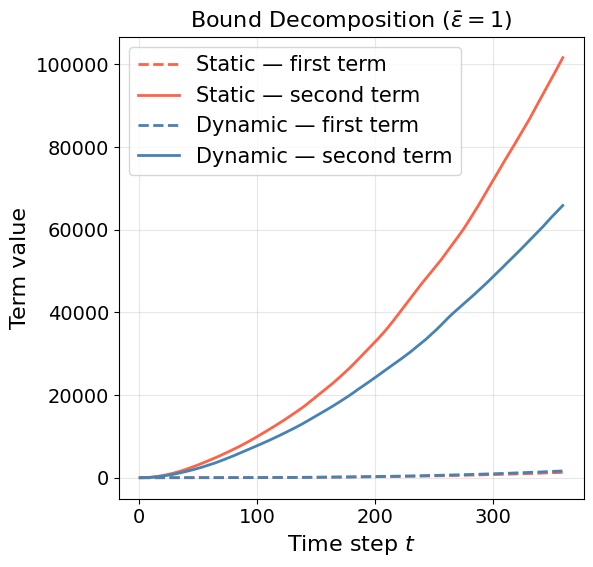

In [23]:
time_steps = 360
eps = 1 

# Plot first term vs second term
x_range = range(1, time_steps)
first_term_array = [first_term(M, gamma, eps, t, A_mat=A_mat, M_phi=M_phi) for t in x_range]
second_term_array = [second_term(M, gamma, eps, t, v_sim, v_hat, rho_sim, rho_hat/lanes, A_mat=A_mat, M_phi=M_phi) for t in x_range]

first_term_array_dyn = [first_term(M_dyn, gamma_dyn, eps, t, A_mat=A_mat_dyn, M_phi=M_phi_dyn) for t in x_range]
second_term_array_dyn = [second_term(M_dyn, gamma_dyn, eps, t, dyn_v_sim, v_hat, dyn_rho_sim, rho_hat/lanes, A_mat=A_mat_dyn, M_phi=M_phi_dyn) for t in x_range]

fig, ax = plt.subplots(figsize=(6, 6))

colors = {'static': 'tomato', 'dynamic': 'steelblue'}

ax.plot(list(x_range), first_term_array,     color=colors['static'],  ls='--', label=r'Static — first term', linewidth=2)
ax.plot(list(x_range), second_term_array,    color=colors['static'],  ls='-',  label=r'Static — second term', linewidth=2)
ax.plot(list(x_range), first_term_array_dyn, color=colors['dynamic'], ls='--', label=r'Dynamic — first term', linewidth=2)
ax.plot(list(x_range), second_term_array_dyn,color=colors['dynamic'], ls='-',  label=r'Dynamic — second term', linewidth=2)

ax.set_xlabel('Time step $t$', fontsize=16)
ax.set_ylabel('Term value', fontsize=16)
ax.set_title(r'Bound Decomposition ($\bar \varepsilon=1$)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=15)
ax.grid(True, alpha=0.3)

plt.savefig('ub_terms.png', bbox_inches='tight')
plt.show()
# print(f"first term: {first_term(M, gamma, eps, time_steps, A_mat=A_mat, M_phi=M_phi)}")
# print(f"second term: {second_term(M, gamma, eps, time_steps, v_sim, v_hat, rho_sim, rho_hat/lanes, A_mat=A_mat, M_phi=M_phi)}")

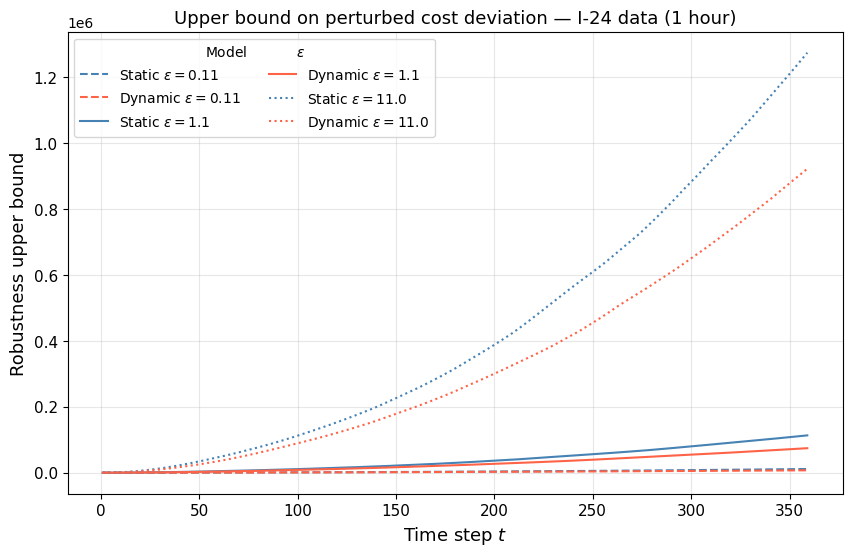

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

eps_values = [0.11, 1.1, 11.0]
linestyles = ['--', '-', ':']
colors = {'static': 'steelblue', 'dynamic': 'tomato'}

for eps, ls in zip(eps_values, linestyles):
    first_term_array = [first_term(M, gamma, eps, t, A_mat=A_mat, M_phi=M_phi) for t in x_range]
    second_term_array = [second_term(M, gamma, eps, t, v_sim, v_hat, rho_sim, rho_hat/lanes, A_mat=A_mat, M_phi=M_phi) for t in x_range]

    first_term_array_dyn = [first_term(M_dyn, gamma_dyn, eps, t, A_mat=A_mat_dyn, M_phi=M_phi_dyn) for t in x_range]
    second_term_array_dyn = [second_term(M_dyn, gamma_dyn, eps, t, dyn_v_sim, v_hat, dyn_rho_sim, rho_hat/lanes, A_mat=A_mat_dyn, M_phi=M_phi_dyn) for t in x_range]

    ub_static  = np.array(first_term_array) + np.array(second_term_array)
    ub_dynamic = np.array(first_term_array_dyn) + np.array(second_term_array_dyn)

    ax.plot(list(x_range), ub_static,  color=colors['static'],  ls=ls, label=rf'Static $\varepsilon={eps}$')
    ax.plot(list(x_range), ub_dynamic, color=colors['dynamic'], ls=ls, label=rf'Dynamic $\varepsilon={eps}$')

# Clean up legend: group by color/style with a two-column layout
ax.legend(ncol=2, fontsize=10, title=r'Model $\quad\quad\quad$ $\varepsilon$')

ax.set_xlabel('Time step $t$', fontsize=13)
ax.set_ylabel(r'Robustness upper bound', fontsize=13)
ax.set_title('Upper bound on perturbed cost deviation — I-24 data (1 hour)', fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, alpha=0.3)

plt.savefig('robustness_upper_bound.png', bbox_inches='tight')
plt.show()

In [30]:
print(np.max(data_inflow))
print(np.max(data_inflow) * 0.01/ 100 * 1.96)

6332.000400000024
1.2410720784000047


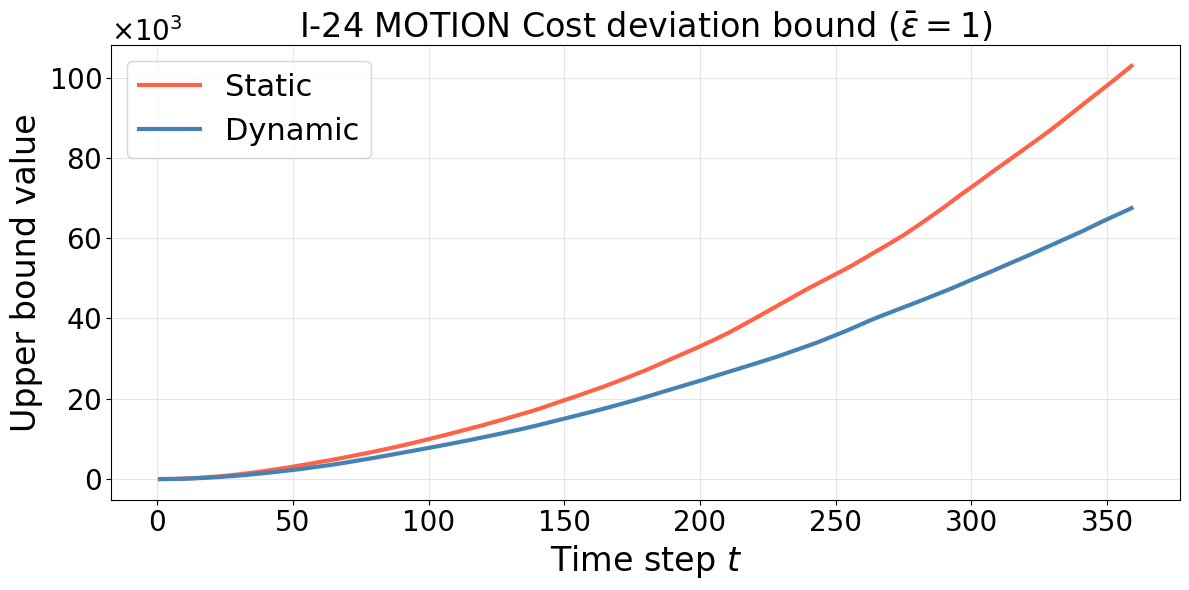

In [25]:
from matplotlib.ticker import ScalarFormatter

time_steps = 360
eps = 1
x_range = range(1, time_steps)

plt.rcParams.update({
    'axes.labelsize':  24,
    'axes.titlesize':  24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 22,
    'legend.title_fontsize': 13,
})

first_term_array     = [first_term(M, gamma, eps, t, A_mat=A_mat, M_phi=M_phi) for t in x_range]
second_term_array    = [second_term(M, gamma, eps, t, v_sim, v_hat, rho_sim, rho_hat/lanes, A_mat=A_mat, M_phi=M_phi) for t in x_range]
first_term_array_dyn = [first_term(M_dyn, gamma_dyn, eps, t, A_mat=A_mat_dyn, M_phi=M_phi_dyn) for t in x_range]
second_term_array_dyn= [second_term(M_dyn, gamma_dyn, eps, t, dyn_v_sim, v_hat, dyn_rho_sim, rho_hat/lanes, A_mat=A_mat_dyn, M_phi=M_phi_dyn) for t in x_range]

ub_static  = np.array(first_term_array) + np.array(second_term_array)
ub_dynamic = np.array(first_term_array_dyn) + np.array(second_term_array_dyn)

colors  = {'static': 'tomato', 'dynamic': 'steelblue'}
linewid = 3

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((3, 3))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(list(x_range), ub_static,  color=colors['static'],  lw=linewid, label='Static')
ax.plot(list(x_range), ub_dynamic, color=colors['dynamic'], lw=linewid, label='Dynamic')

ax.set_xlabel('Time step $t$')
ax.set_ylabel(r'Upper bound value')
ax.set_title(r'I-24 MOTION Cost deviation bound ($\bar\varepsilon=1$)')
ax.yaxis.set_major_formatter(formatter)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ub_static_dynamic.png', bbox_inches='tight')
plt.show()

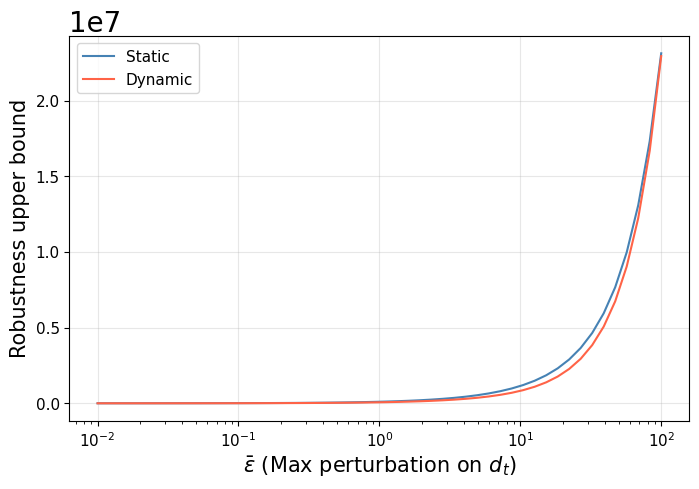

In [21]:
import numpy as np
import matplotlib.pyplot as plt

eps_values = np.logspace(-2, 2, 50)  # 0.01 to 100 in log space

time_steps = 360
x_range = range(1, time_steps)

ub_static_vs_eps  = []
ub_dynamic_vs_eps = []

for eps in eps_values:
    first_term_array = [first_term(M, gamma, eps, t, A_mat=A_mat, M_phi=M_phi) for t in x_range]
    second_term_array = [second_term(M, gamma, eps, t, v_sim, v_hat, rho_sim, rho_hat/lanes, A_mat=A_mat, M_phi=M_phi) for t in x_range]

    first_term_array_dyn = [first_term(M_dyn, gamma_dyn, eps, t, A_mat=A_mat_dyn, M_phi=M_phi_dyn) for t in x_range]
    second_term_array_dyn = [second_term(M_dyn, gamma_dyn, eps, t, dyn_v_sim, v_hat, dyn_rho_sim, rho_hat/lanes, A_mat=A_mat_dyn, M_phi=M_phi_dyn) for t in x_range]

    ub_static  = np.array(first_term_array) + np.array(second_term_array)
    ub_dynamic = np.array(first_term_array_dyn) + np.array(second_term_array_dyn)

    # Choose one: final value, sum, or mean over time
    ub_static_vs_eps.append(ub_static[-1])    # final timestep
    ub_dynamic_vs_eps.append(ub_dynamic[-1])  # swap for .sum() or .mean() if preferred

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(eps_values, ub_static_vs_eps,  color='steelblue', label='Static')
ax.plot(eps_values, ub_dynamic_vs_eps, color='tomato',    label='Dynamic')

ax.set_xlabel(r'$\bar \varepsilon$ (Max perturbation on $d_t$)', fontsize=15)
ax.set_ylabel(r'Robustness upper bound', fontsize=15)
# ax.set_title('Robustness upper bound vs. $\\varepsilon$ — I-24 data (1 hour)', fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')


plt.savefig('ub_vs_epsilon.png', bbox_inches='tight')
plt.show()

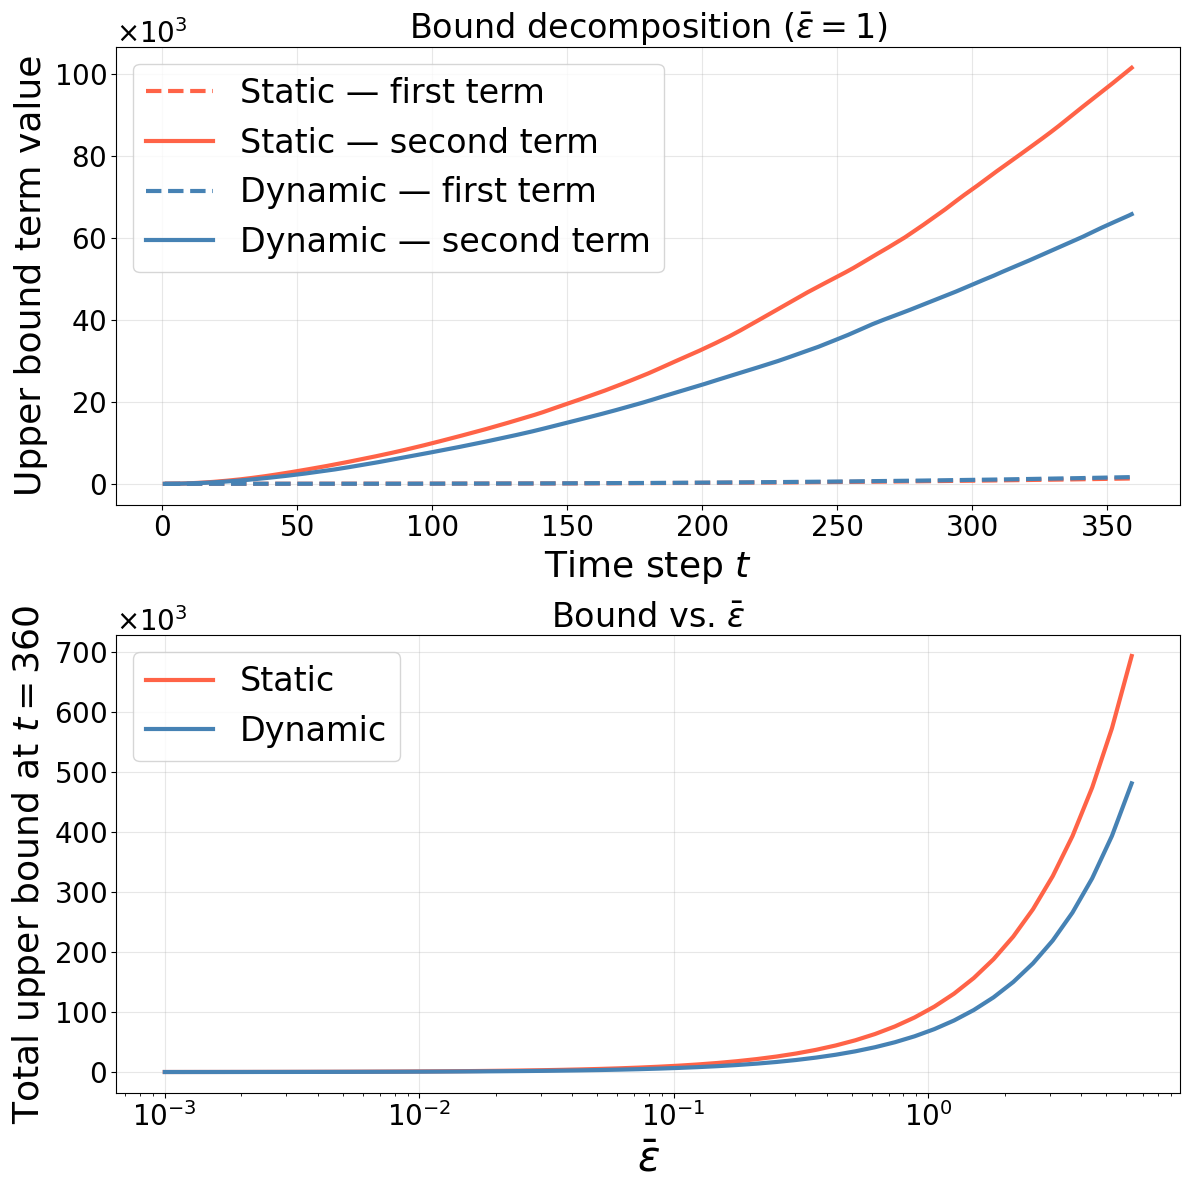

In [27]:
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({
    'axes.labelsize':  26,
    'axes.titlesize':  24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 24,
    'legend.title_fontsize': 13,
})

fig, axes = plt.subplots(2, 1, figsize=(12, 12))
colors = {'static': 'tomato', 'dynamic': 'steelblue'}

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((3, 3))

linewid = 3

# --- Left: Bound decomposition ---
ax = axes[0]
ax.plot(list(x_range), first_term_array,      color=colors['static'],  ls='--', lw=linewid, label=r'Static — first term')
ax.plot(list(x_range), second_term_array,     color=colors['static'],  ls='-',  lw=linewid, label=r'Static — second term')
ax.plot(list(x_range), first_term_array_dyn,  color=colors['dynamic'], ls='--', lw=linewid, label=r'Dynamic — first term')
ax.plot(list(x_range), second_term_array_dyn, color=colors['dynamic'], ls='-',  lw=linewid, label=r'Dynamic — second term')

ax.set_xlabel('Time step $t$')
ax.set_ylabel('Upper bound term value')
ax.set_title(r'Bound decomposition ($\bar \varepsilon=1$)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(formatter)

# --- Right: Bound vs epsilon ---
ax = axes[1]

eps_values = np.logspace(-3, 0.8, 50)
ub_static_vs_eps, ub_dynamic_vs_eps = [], []

for eps in eps_values:
    ft     = np.array([first_term(M, gamma, eps, t, A_mat=A_mat, M_phi=M_phi) for t in x_range])
    st     = np.array([second_term(M, gamma, eps, t, v_sim, v_hat, rho_sim, rho_hat/lanes, A_mat=A_mat, M_phi=M_phi) for t in x_range])
    ft_dyn = np.array([first_term(M_dyn, gamma_dyn, eps, t, A_mat=A_mat_dyn, M_phi=M_phi_dyn) for t in x_range])
    st_dyn = np.array([second_term(M_dyn, gamma_dyn, eps, t, dyn_v_sim, v_hat, dyn_rho_sim, rho_hat/lanes, A_mat=A_mat_dyn, M_phi=M_phi_dyn) for t in x_range])

    ub_static_vs_eps.append((ft + st)[-1])
    ub_dynamic_vs_eps.append((ft_dyn + st_dyn)[-1])

ax.plot(eps_values, ub_static_vs_eps,  color=colors['static'],  lw=linewid, label='Static')
ax.plot(eps_values, ub_dynamic_vs_eps, color=colors['dynamic'], lw=linewid, label='Dynamic')
ax.yaxis.set_major_formatter(formatter)
ax.set_xscale('log')
ax.set_xlabel(r'$\bar \varepsilon$', fontsize=30)
ax.set_ylabel(r'Total upper bound at $t=360$')
ax.set_title(r'Bound vs. $\bar \varepsilon$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ub_combined.png', bbox_inches='tight')
plt.show()

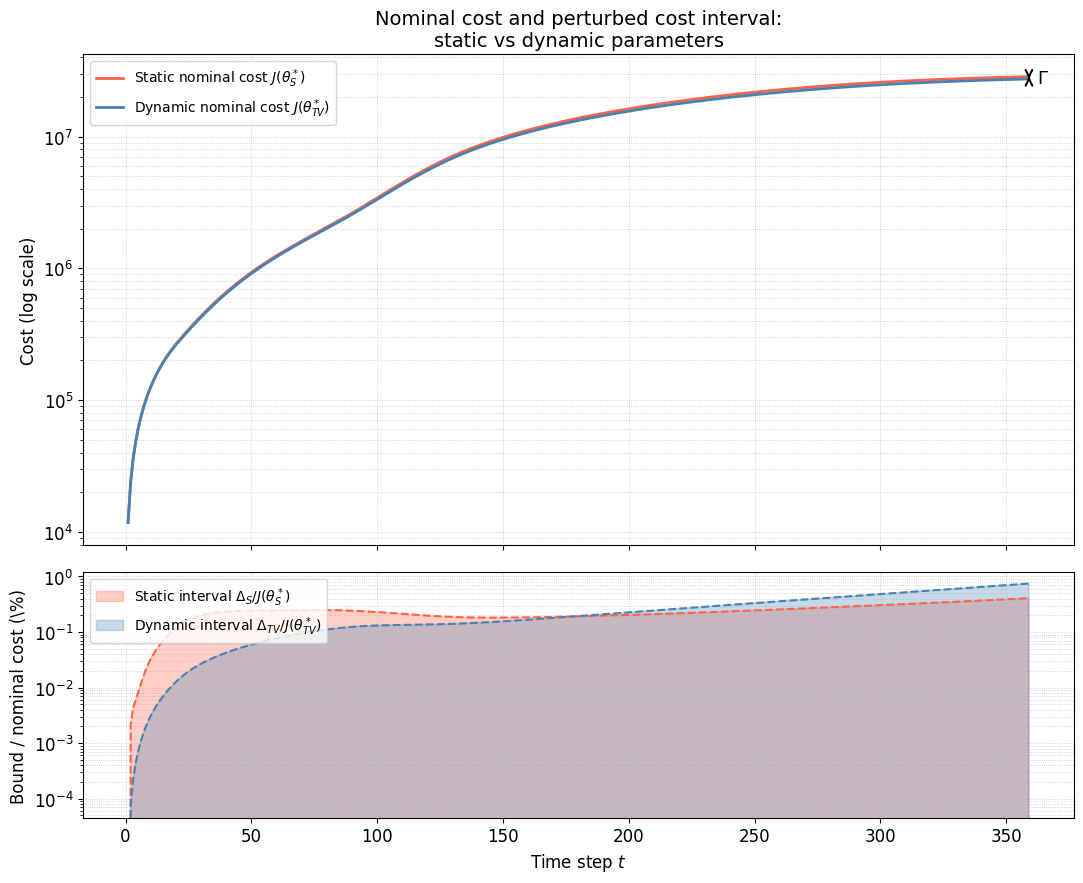

In [667]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 9),
                                      sharex=True,
                                      gridspec_kw={'height_ratios': [2, 1]})

# ── TOP PANEL: nominal cost lines only ──────────────────────────────────────
cost_static  = np.array(cost_static)
cost_dynamic = np.array(cost_dynamic)
ub_static    = np.array(ub_static)
ub_dynamic   = np.array(ub_dynamic)

ax_top.plot(x_range, cost_static,
            color='tomato', linewidth=2,
            label='Static nominal cost $J(\\theta^*_S)$')
ax_top.plot(x_range, cost_dynamic,
            color='steelblue', linewidth=2,
            label='Dynamic nominal cost $J(\\theta^*_{TV})$')

# annotate Gamma gap at final timestep
t_annot   = x_range[-1]
y_static  = cost_static[-1]
y_dynamic = cost_dynamic[-1]
ax_top.annotate('',
                xy=(t_annot, y_dynamic),
                xytext=(t_annot, y_static),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax_top.text(t_annot + 3, (y_static + y_dynamic) / 2,
            '$\\Gamma$', fontsize=13, va='center')

ax_top.set_yscale('log')
ax_top.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax_top.set_ylabel('Cost (log scale)', fontsize=12)
ax_top.set_title('Nominal cost and perturbed cost interval:\n'
                 'static vs dynamic parameters', fontsize=14)
ax_top.grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.7)
ax_top.legend(fontsize=10, loc='upper left')

# ── BOTTOM PANEL: bounds as % of nominal cost ────────────────────────────────
upper_static_pct  = (ub_static  / cost_static)  * 100
upper_dynamic_pct = (ub_dynamic / cost_dynamic) * 100

ax_bot.fill_between(x_range, 0, upper_static_pct,
                    alpha=0.30, color='tomato',
                    label='Static interval $\\Delta_S / J(\\theta^*_S)$')
ax_bot.fill_between(x_range, 0, upper_dynamic_pct,
                    alpha=0.30, color='steelblue',
                    label='Dynamic interval $\\Delta_{TV} / J(\\theta^*_{TV})$')
ax_bot.plot(x_range, upper_static_pct,
            color='tomato', linewidth=1.5, linestyle='--')
ax_bot.plot(x_range, upper_dynamic_pct,
            color='steelblue', linewidth=1.5, linestyle='--')

ax_bot.set_yscale('log')
ax_bot.set_xlabel('Time step $t$', fontsize=12)
ax_bot.set_ylabel('Bound / nominal cost (\\%)', fontsize=12)
ax_bot.grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.7)
ax_bot.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('cost_perturbation_static_vs_dynamic.png', dpi=150)
plt.show()

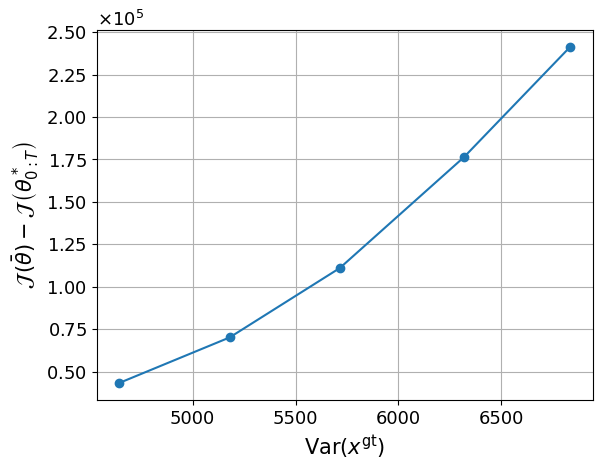

In [52]:
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((5, 5))  # force 1e5 specifically
variances = [0.1, 0.15, 0.2, 0.25, 0.3]
advantage = []
for var in variances:
    # Read noise_robustness_results.csv and extract first values from J_cost column
    dyn_results_path = f"cdc_results/synthetic_data_rain/mpc_calibration_results_var{var}/control_h_1/noise_robustness_results.csv"
    results = np.genfromtxt(dyn_results_path, delimiter=',', names=True)
    J_cost_dyn = results['J_cost'][0]

    results_path = f"cdc_results/synthetic_data_rain/mpc_calibration_results_var{var}/control_h_360/noise_robustness_results.csv"
    results = np.genfromtxt(results_path, delimiter=',', names=True)
    J_cost_stat = results['J_cost'][0]

    advantage.append(J_cost_stat - J_cost_dyn)

plt.plot([4643, 5180, 5715, 6318, 6833], advantage, marker='o')
# Add var (x^gt) as x axis label in latex
mpl.rcParams['text.usetex'] = False
mpl.rcParams['font.size'] = 12

plt.rcParams.update({
    'axes.labelsize':  15,
    'axes.titlesize':  15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 24,
    'legend.title_fontsize': 13,
})

ax = plt.gca()
ax.yaxis.set_major_formatter(formatter)

plt.xlabel(r"Var$(x^{\text{gt}})$")
plt.ylabel(r"$\mathcal{J} \, \left(\bar \theta\right) - \mathcal{J} \,\left(\theta_{0:T}^*\right)$")
plt.grid()

plt.savefig('var_gt.png', dpi=150, bbox_inches='tight')

plt.show()
